# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [1]:
!pip install shap -qU


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -qU pyALE


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install -qU lime fat-forensics[all]


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Подготовка данных**

Загрузите датасет по ссылке.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [ ]:
!wget  -O 'world-happiness-report-2021-prep.csv' -q 'https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=0'

In [2]:
data_to_work = pd.read_csv('world-happiness-report-2021-prep.csv')

data_to_work.head(5)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [3]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [4]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [5]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [6]:
lr_minmax = LinearRegression().fit(X_train_sc_minmax, y_train)
pred = lr_minmax.predict(X_test_sc_minmax)
mse_lr_minmax = mean_squared_error(y_test, pred)
rmse_lr_minmax = root_mean_squared_error(y_test, pred)

lr_std = LinearRegression().fit(X_train_sc_standard, y_train)
pred = lr_std.predict(X_test_sc_standard)
mse_lr_std = mean_squared_error(y_test, pred)
rmse_lr_std = root_mean_squared_error(y_test, pred)


lasso_minmax = Lasso(alpha=0.1, random_state=42).fit(X_train_sc_minmax, y_train)  # добавил альфу, чтобы не занулялос все, а то без нее все признаки занулялись
pred = lasso_minmax.predict(X_test_sc_minmax)
mse_lasso_minmax = mean_squared_error(y_test, pred)
rmse_lasso_minmax = root_mean_squared_error(y_test, pred)

lasso_std = Lasso(alpha=0.1, random_state=42).fit(X_train_sc_standard, y_train)
pred = lasso_std.predict(X_test_sc_standard)
mse_lasso_std = mean_squared_error(y_test, pred)
rmse_lasso_std = root_mean_squared_error(y_test, pred)


gbr_minmax = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_sc_minmax, y_train)
pred = gbr_minmax.predict(X_test_sc_minmax)
mse_gbr_minmax = mean_squared_error(y_test, pred)
rmse_gbr_minmax = root_mean_squared_error(y_test, pred)

gbr_std = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_sc_standard, y_train)
pred = gbr_std.predict(X_test_sc_standard)
mse_gbr_std = mean_squared_error(y_test, pred)
rmse_gbr_std = root_mean_squared_error(y_test, pred)


print(f"Linear minmax: MSE = {mse_lr_minmax}, RMSE = {rmse_lr_minmax}")
print(f"Linear std: MSE = {mse_lr_std}, RMSE = {rmse_lr_std}")
print(f"Lasso minmax: MSE = {mse_lasso_minmax}, RMSE = {rmse_lasso_minmax}")
print(f"Lasso std: MSE = {mse_lasso_std}, RMSE = {rmse_lasso_std}")
print(f"GradientBoostingRegressor minmax: MSE = {mse_gbr_minmax}, RMSE = {rmse_gbr_minmax}")
print(f"GradientBoostingRegressor std: MSE = {mse_gbr_std}, RMSE = {rmse_gbr_std}")

Linear minmax: MSE = 9.8419022351019e-07, RMSE = 0.0009920636186808737
Linear std: MSE = 9.841902235101707e-07, RMSE = 0.000992063618680864
Lasso minmax: MSE = 0.4887543770405635, RMSE = 0.6991097031514893
Lasso std: MSE = 0.02981211894866824, RMSE = 0.17266186304065018
GradientBoostingRegressor minmax: MSE = 0.15308523050127568, RMSE = 0.3912610771611146
GradientBoostingRegressor std: MSE = 0.1530731219790113, RMSE = 0.39124560314335965


Выводы:

Видим, что значения при разных вариантах масштабирования практические не отличаются, но lasso показало значительное отличие в точности на фоне остальных моделей.

## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

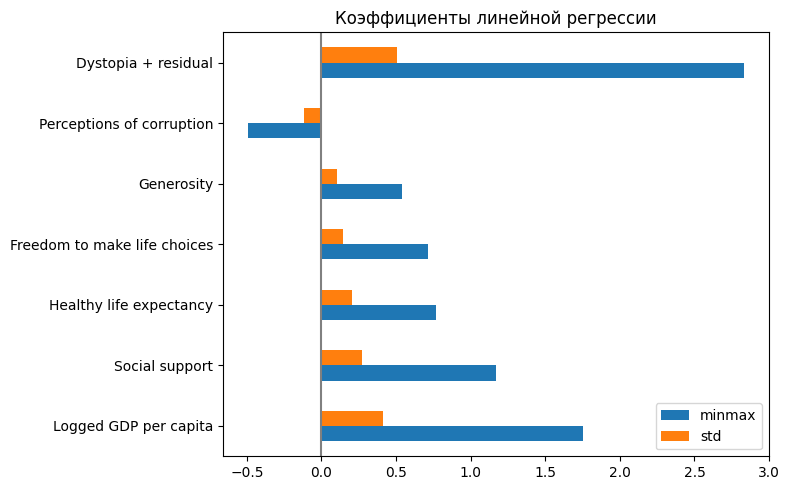

In [7]:
# Ваш код здесь — LR + два варианта
coef_lr = pd.DataFrame({
    'minmax': lr_minmax.coef_,
    'std': lr_std.coef_
}, index=feature_names)

coef_lr.plot(kind='barh', figsize=(8, 5))
plt.title('Коэффициенты линейной регрессии')
plt.axvline(0, color='grey')
plt.tight_layout()
plt.show()

**Ваш вывод здесь:**

Для линейной модели при разном масштабировании будут меняться значения коэффициентов, поэтому какие-либо рассуждения об интерпретации признаков разумно делать только в рамках одного масштаба. Однако расставление признаков по порядку важности будет то же независимо от масштаба, проблемы лишь в значениях.

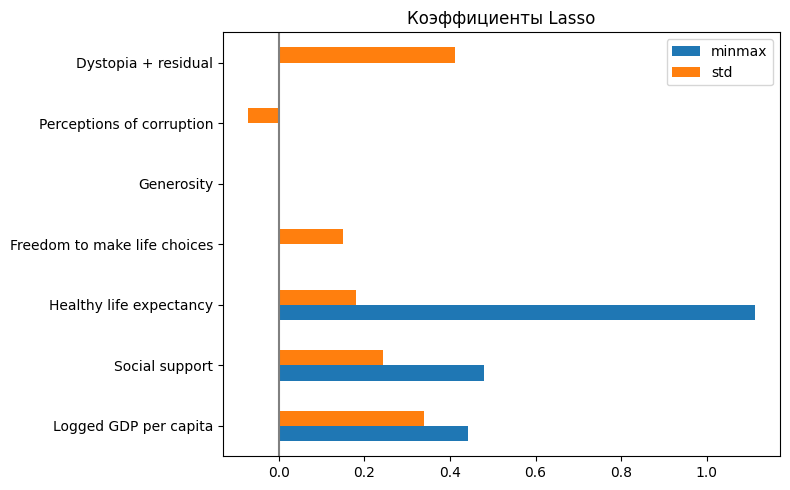

In [8]:
# Ваш код здесь — Lasso + два варианта
coef_lasso = pd.DataFrame({
    'minmax': lasso_minmax.coef_,
    'std': lasso_std.coef_
}, index=feature_names)

coef_lasso.plot(kind='barh', figsize=(8, 5))
plt.title('Коэффициенты Lasso')
plt.axvline(0, color='grey')
plt.tight_layout()
plt.show()

**Ваш вывод здесь:**

Касательно выбора масштаба мы понимаем, что в зависимости от масштабирования меняются веса и, соответсвенно, штрафы в lasso, поэтому важно придерживаться одной методики масштабирования, чтобы сделать отбор признаков стабильным.

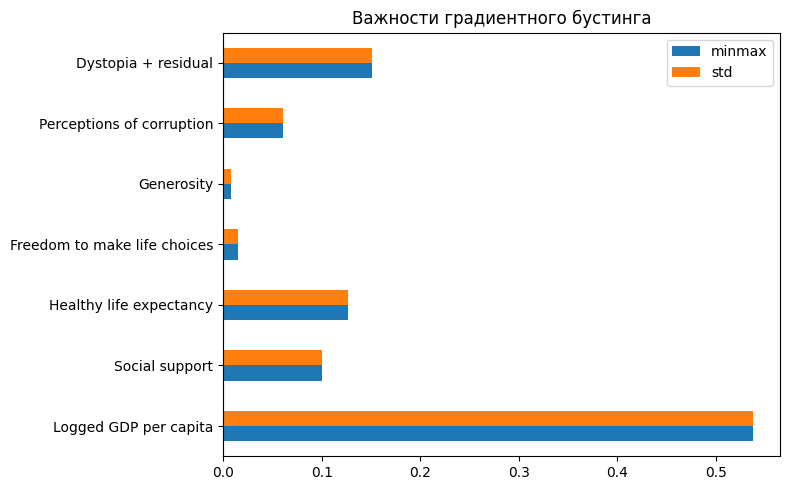

In [9]:
# Ваш код здесь GB + два варианта
gb = pd.DataFrame({
    'minmax': gbr_minmax.feature_importances_,
    'std': gbr_std.feature_importances_
}, index=feature_names)

gb.plot(kind='barh', figsize=(8, 5))
plt.title('Важности градиентного бустинга')
plt.axvline(0, color='grey')
plt.tight_layout()
plt.show()

**Ваш вывод здесь:**

В случае же деревьев выбранный масштаб роли не играет, поэтому можно спокойно интерпретировать результаты независимо от масштабирования. 

Можно заметить, что разные модели присваивают разные важности каждому признаку (если ставить по порядку). В случае lasso я думаю, что это просто некачественная модель. В остальных случаях результаты +- схожие. 

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:**

Пусть для признака $j$:
- $a_j = \frac{1}{\max_j - \min_j}$ (масштаб MinMax, `sc_minmax.scale_`),
- $c_{1j} = -\frac{\min_j}{\max_j - \min_j}$ (сдвиг MinMax, `sc_minmax.min_`),
- $b_j = \frac{1}{\sigma_j}$ (масштаб Standard, `1 / sc_standard.scale_`),  
  но в коде удобнее использовать $\sigma_j$ (`sc_standard.scale_`),
- $c_{2j} = -\frac{\mu_j}{\sigma_j}$ (сдвиг Standard).

Модель даёт одинаковый прогноз:  
$\sum w_{mm}^{(j)} (a_j x_j + c_{1j}) + b_{mm} = \sum w_{std}^{(j)} (b_j x_j + c_{2j}) + b_{std}$.

Приравнивая слагаемые при $x_j$ и свободные члены, получаем:

$$
w_{std}^{(j)} = w_{mm}^{(j)} \cdot \frac{\sigma_j}{\max_j - \min_j}
\qquad\Longleftrightarrow\qquad
\boxed{\;w_{std} = w_{mm} \;\times\; \texttt{minmax\_scale} \;\times\; \texttt{sc\_standard.scale\_}\;}
$$

$$
b_{std} = b_{mm} + \sum w_{mm}^{(j)}\Bigl(-\frac{\min_j}{\max_j - \min_j}\Bigr) + \sum w_{std}^{(j)}\frac{\mu_j}{\sigma_j}
\qquad\Longleftrightarrow\qquad
\boxed{\;b_{std} = b_{mm} + w_{mm}^T \times \texttt{minmax\_min} + w_{std}^T \times \bigl(\texttt{mean}/\texttt{scale}\bigr)\;}
$$

Именно эти формулы реализованы в коде.

In [10]:
minmax_scale = sc_minmax.scale_
minmax_min = sc_minmax.min_

w_minmax = lr_minmax.coef_
b_minmax = lr_minmax.intercept_

coef_std = w_minmax * minmax_scale * sc_standard.scale_
intercept_std = b_minmax + np.dot(w_minmax, minmax_min) + np.dot(coef_std, sc_standard.mean_ / sc_standard.scale_)

assert round(intercept_std, 4) == round(lr_std.intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(lr_std.coef_, 4))

## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [11]:
lr_minmax = lr_minmax # модель LinearRegression, обученная на X_train_sc_minmax
gb_minmax = gbr_minmax # модель GradientBoostingRegressor, обученная на X_train_sc_minmax

### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


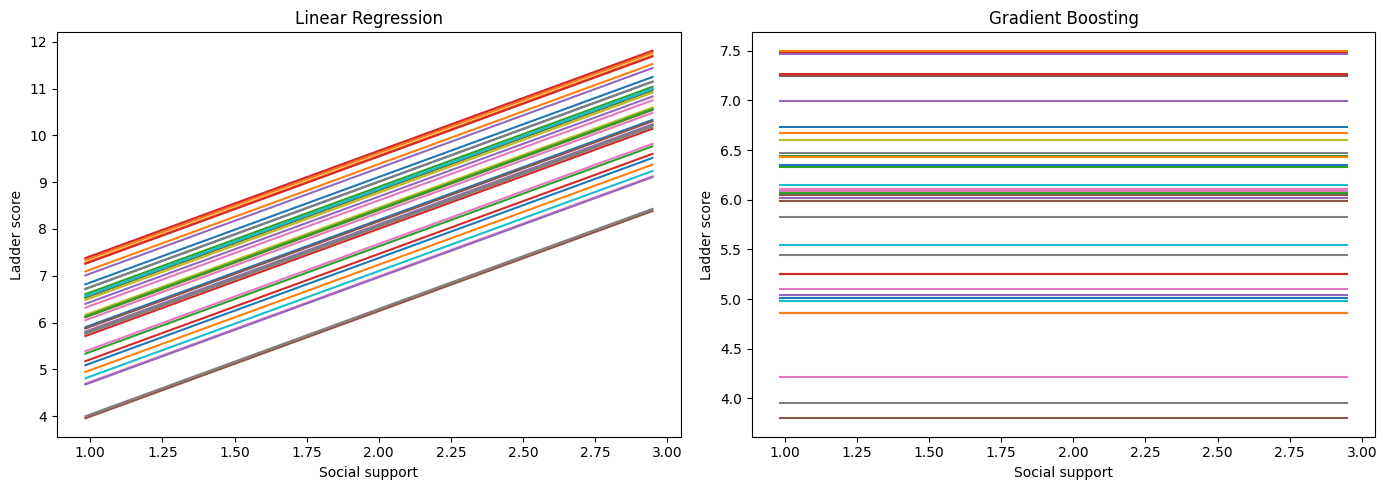

In [12]:
orig_min = X[feature_name].min()
orig_max = X[feature_name].max()

grid = np.linspace(orig_max, 3 * orig_max, 20)
min = sc_minmax.data_min_[feature_idx]
max = sc_minmax.data_max_[feature_idx]
grid_scaled = (grid - min) / (max - min)

n = len(grid_scaled)
samples = X_test_sc_minmax.shape[0]
ice_lr = np.zeros((n, samples))
ice_gb = np.zeros((n, samples))

for i in range(n):
    temp = X_test_sc_minmax.copy()
    temp[:, feature_idx] = grid_scaled[i]
    ice_lr[i, :] = lr_minmax.predict(temp)
    ice_gb[i, :] = gb_minmax.predict(temp)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(grid, ice_lr)
plt.title('Linear Regression')
plt.xlabel(f'{feature_name}')
plt.ylabel('Ladder score')

plt.subplot(1, 2, 2)
plt.plot(grid, ice_gb)
plt.title('Gradient Boosting')
plt.xlabel(f'{feature_name}')
plt.ylabel('Ladder score')

plt.tight_layout()
plt.show()

**Ваш вывод здесь:**

Видим, что в бустинге это не повлияло на прогноз и все значения просто видимо попали в одну и ту же терминальную вершину, что дает одни и те же значения прогноза. В случае линейной регрессии мы просто наблюдаем линейный рост соответсвующий значению коэффициента перед выбранным признаком.

Из этого можно сделать вывод, что в деревьях крайне важно обучать модель на наблюдениях со значениями больше 1, если мы такие тоже хотим корректно прогнозировать, а иначе мы просто будем все сильно обобщать.



### **1. 2. PDP**

Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


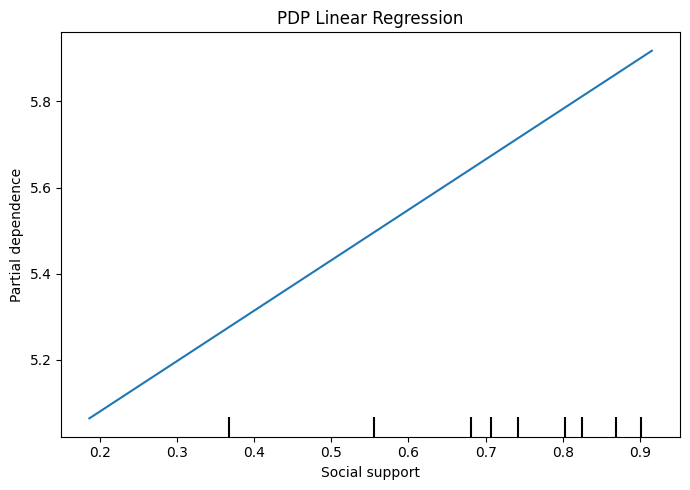

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    lr_minmax, X_test_sc_minmax, features=[feature_idx], feature_names=feature_names, ax=ax
)
ax.set_title('PDP Linear Regression')
ax.set_xlabel(feature_name)
plt.tight_layout()
plt.show()

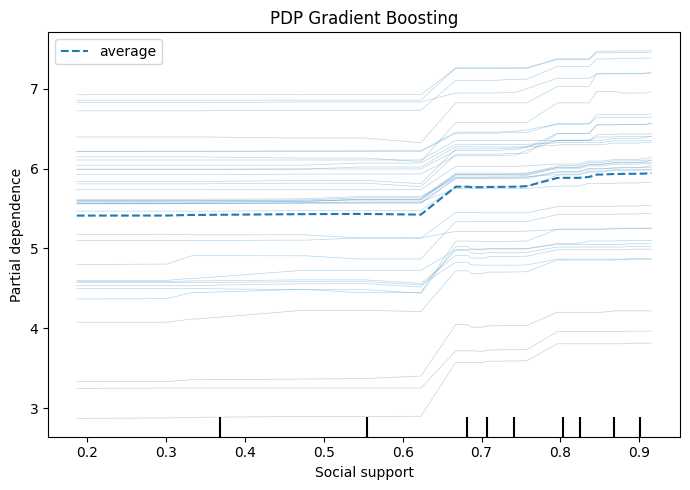

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    gb_minmax, X_test_sc_minmax, features=[feature_idx], feature_names=feature_names, kind='both', ax=ax
)
ax.set_title('PDP Gradient Boosting')
ax.set_xlabel(feature_name)
plt.tight_layout()
plt.show()

**Ваш вывод здесь:**

Видим, что в линейной модели просто линейная зависимости и прогнозы соответственно. В бустинге же мы получаем лесенку, это тоже вполне логично, потому что это просто описывает то, в какую вершину мы попадаем, что и дает одинаковые прогнозы для +- одинаковых значений признака. Чем более сложная структура дерева, тем больше ступеней должно получаться на графике.

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.


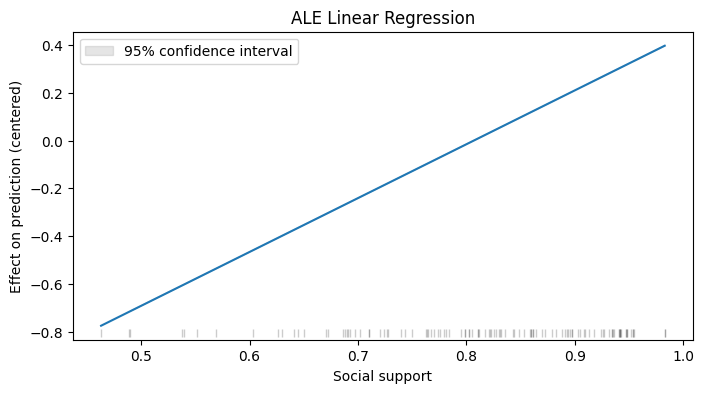

In [15]:
from PyALE import ale

class Wrap:
    def __init__(self, model, scaler):
        self.model = model
        self.scaler = scaler
    def predict(self, X):
        X_sc = self.scaler.transform(X)
        return self.model.predict(X_sc)

ale(
    X=X_train[feature_names],
    model=Wrap(lr_minmax, sc_minmax),
    feature=[feature_name],
    grid_size=50,
    include_CI=True,
    plot=True
)
plt.title('ALE Linear Regression')
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


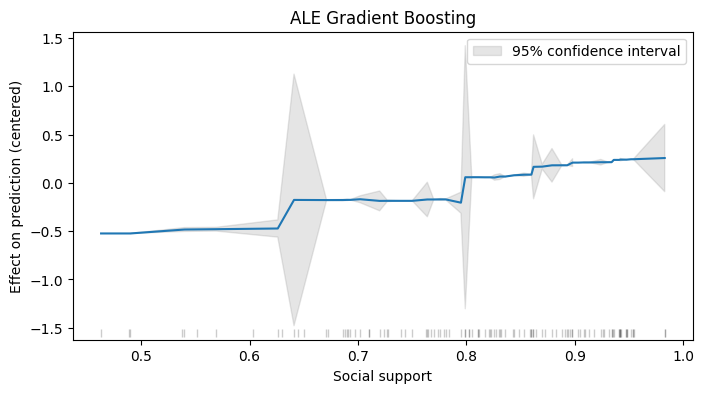

In [16]:
ale(
    X=X_train[feature_names],
    model=Wrap(gb_minmax, sc_minmax),
    feature=[feature_name],
    grid_size=50,
    include_CI=True,
    plot=True
)
plt.title('ALE Gradient Boosting')
plt.show()

**Ваши выводы здесь:**

В случае линейной регрессии ДИ не будут особо видны (либо вообще не будут расширять область), потому что модель очень стабильна и при бутстрапе ничего особо и не поменяется (коэффициенты те же будут). Из-за этого значения график получается весьма точным.

В случае бустинга мы получаем сильный разброс на граничных значениях (края ступенек), потому что туда попадает малое количество наблюдений, что ухудшает стабильность и увеличивает неопределенность. Также при малых бустрап-выборках граничных значений попадает еще меньше, что еще больше увеличивает разброс и неопределенность ALE. 

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

In [17]:
from sklearn.inspection import permutation_importance

In [18]:
values = [3, 5, 7, 10, 12, 15, 17, 20, 30, 40, 50, 60, 75, 85, 100]

lr_means = {feat: [] for feat in feature_names}
lr_stds  = {feat: [] for feat in feature_names}
gb_means = {feat: [] for feat in feature_names}
gb_stds  = {feat: [] for feat in feature_names}

for n in values:
    print(f'\nn = {n}')
    imp_lr = permutation_importance(lr_minmax, X_test_sc_minmax, y_test,
                                    n_repeats=n, random_state=42)
    df_lr = pd.DataFrame({'feature': feature_names,
                          'importances': imp_lr.importances_mean,
                          'importances_std': imp_lr.importances_std})
    print('\nLinear Regression')
    print(df_lr.to_string(index=False))

    imp_gb = permutation_importance(gb_minmax, X_test_sc_minmax, y_test,
                                    n_repeats=n, random_state=42)
    df_gb = pd.DataFrame({'feature': feature_names,
                          'importances': imp_gb.importances_mean,
                          'importances_std': imp_gb.importances_std})
    print('\nGradient Boosting')
    print(df_gb.to_string(index=False))

    for i in range(len(feature_names)):
        feat = feature_names[i]
        lr_means[feat].append(imp_lr.importances_mean[i])
        lr_stds[feat].append(imp_lr.importances_std[i])
        gb_means[feat].append(imp_gb.importances_mean[i])
        gb_stds[feat].append(imp_gb.importances_std[i])


n = 3

Linear Regression
                     feature  importances  importances_std
       Logged GDP per capita     0.262088         0.033264
              Social support     0.095257         0.027261
     Healthy life expectancy     0.103153         0.014492
Freedom to make life choices     0.027133         0.004495
                  Generosity     0.009799         0.000943
   Perceptions of corruption     0.023755         0.004018
         Dystopia + residual     0.729305         0.092679

Gradient Boosting
                     feature  importances  importances_std
       Logged GDP per capita     0.367821         0.066645
              Social support     0.054845         0.033810
     Healthy life expectancy     0.021191         0.019486
Freedom to make life choices     0.007254         0.013402
                  Generosity     0.004514         0.002298
   Perceptions of corruption    -0.038162         0.012215
         Dystopia + residual     0.381809         0.048996

n = 5

Lin

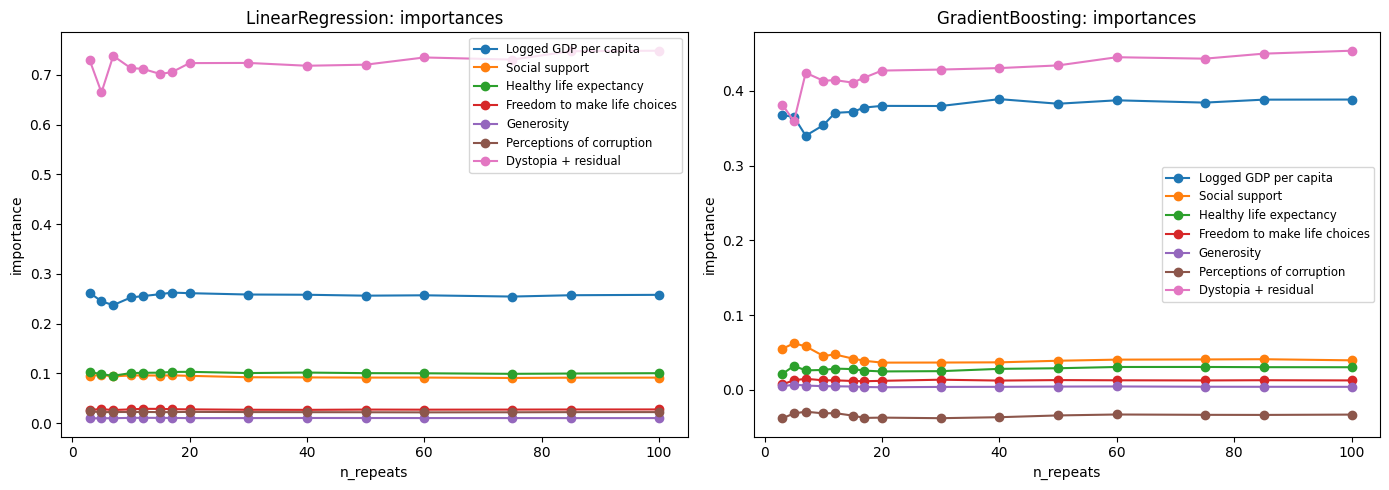

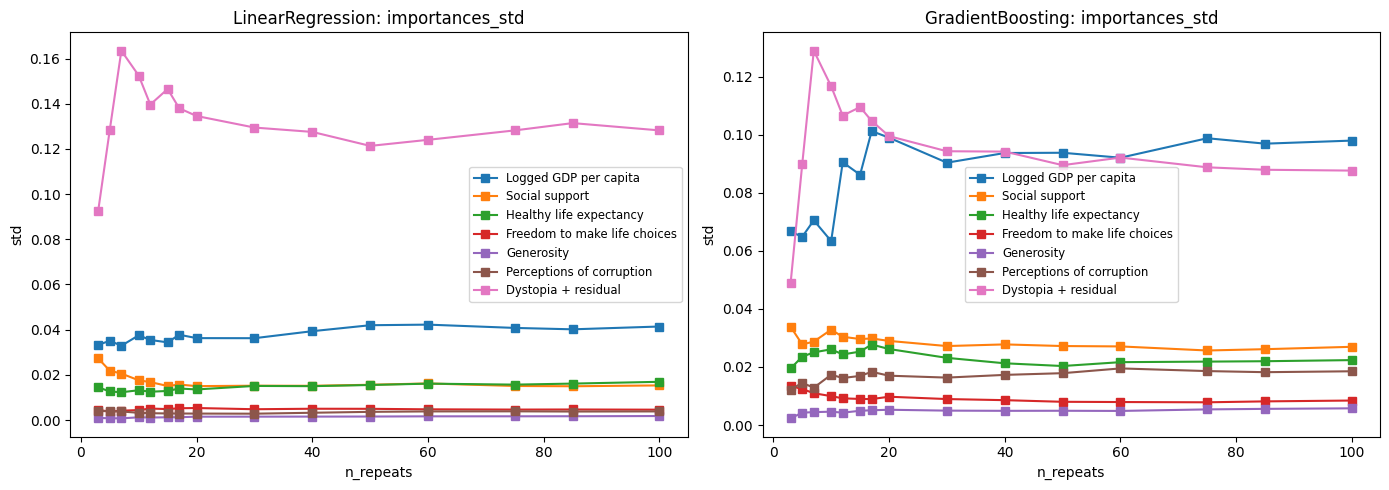

In [19]:
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for feat in feature_names:
    ax1.plot(values, lr_means[feat], marker='o', label=feat)
    ax2.plot(values, gb_means[feat], marker='o', label=feat)
ax1.set_title('LinearRegression: importances')
ax2.set_title('GradientBoosting: importances')
for ax in (ax1, ax2):
    ax.set_xlabel('n_repeats')
    ax.set_ylabel('importance')
    ax.legend(fontsize='small', loc='best')
plt.tight_layout()
plt.show()

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))
for feat in feature_names:
    ax3.plot(values, lr_stds[feat], marker='s', label=feat)
    ax4.plot(values, gb_stds[feat], marker='s', label=feat)
ax3.set_title('LinearRegression: importances_std')
ax4.set_title('GradientBoosting: importances_std')
for ax in (ax3, ax4):
    ax.set_xlabel('n_repeats')
    ax.set_ylabel('std')
    ax.legend(fontsize='small', loc='best')
plt.tight_layout()
plt.show()


**Ваши выводы здесь:**

В линейной модели сами значения коэффициентов не особо меняются при росте n, поскольку модель достаточно простая и стабильная. В случае бустинга заметен небольшой рост значения коэффициентов с ростом n, возможно это связано с большей нестабильностью и неопределенностью модели. 

Также на маленьких значения n обе модели сильно колеблются и имееют как правило наибльшие значения std. Еще видно, что у линейной модели для каждого признака std КАК ПРАВИЛО меньше при одинаковых n. Еще видим, что все значения больше стабилизируются при увеличении n

### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



In [20]:
def occlusion_importance(model, X, y, values, base_values):
    pred = model.predict(X)
    mse = mean_squared_error(y, pred)
    res = {}
    for b in values:
        importances = []
        for j in range(X.shape[1]):
            X_new = X.copy()
            X_new[:, j] = (1 - b) * X_new[:, j] + b * base_values[j]
            pred_new = model.predict(X_new)
            mse_new = mean_squared_error(y, pred_new)
            importances.append(mse_new - mse)
        res[b] = np.array(importances)
    return res


beta = 0.2
                     feature  delta MSE
       Logged GDP per capita  -0.023991
              Social support  -0.008040
     Healthy life expectancy  -0.001092
Freedom to make life choices  -0.000280
                  Generosity   0.000327
   Perceptions of corruption   0.003981
         Dystopia + residual  -0.016285

beta = 0.5
                     feature  delta MSE
       Logged GDP per capita   0.070429
              Social support  -0.021639
     Healthy life expectancy  -0.003836
Freedom to make life choices  -0.001742
                  Generosity   0.003107
   Perceptions of corruption  -0.032307
         Dystopia + residual   0.049899

beta = 1.0
                     feature  delta MSE
       Logged GDP per capita   0.152120
              Social support  -0.002746
     Healthy life expectancy  -0.005259
Freedom to make life choices   0.003293
                  Generosity   0.001821
   Perceptions of corruption  -0.057390
         Dystopia + residual   0.281525


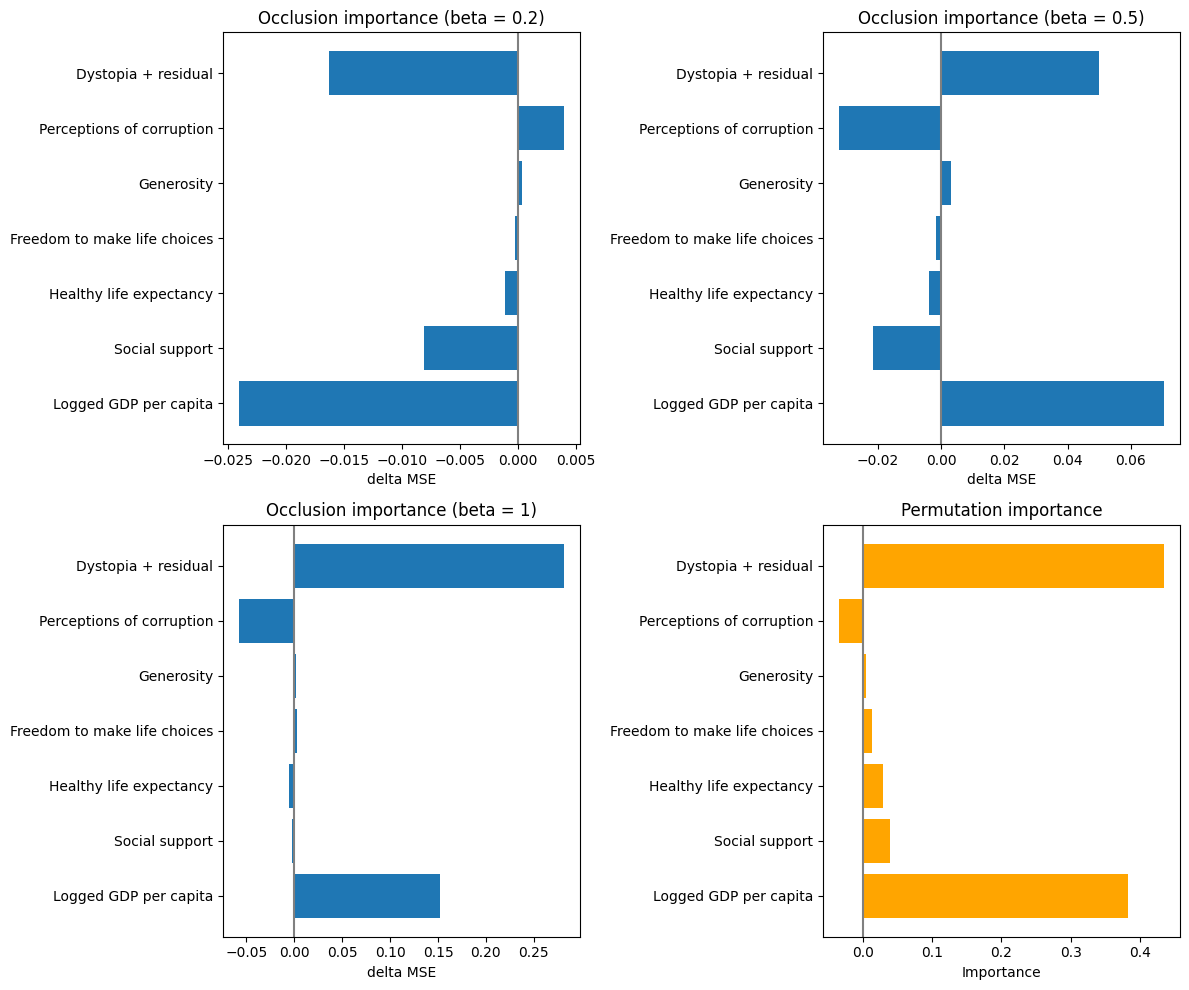

In [21]:
oc = occlusion_importance(gb_minmax, X_test_sc_minmax, y_test, [0.2, 0.5, 1.0], np.median(X_train_sc_minmax, axis=0))

for b, imp in oc.items():
    print(f"\nbeta = {b}")
    df = pd.DataFrame({'feature': feature_names, 'delta MSE': imp})
    print(df.to_string(index=False))

perm_importances = permutation_importance(gb_minmax, X_test_sc_minmax, y_test, n_repeats=50, random_state=42).importances_mean

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax0 = axes[0, 0]
ax0.barh(feature_names, oc[0.2])
ax0.set_title('Occlusion importance (beta = 0.2)')
ax0.set_xlabel('delta MSE')
ax0.axvline(0, color='gray')

ax1 = axes[0, 1]
ax1.barh(feature_names, oc[0.5])
ax1.set_title('Occlusion importance (beta = 0.5)')
ax1.set_xlabel('delta MSE')
ax1.axvline(0, color='gray')

ax2 = axes[1, 0]
ax2.barh(feature_names, oc[1.0])
ax2.set_title('Occlusion importance (beta = 1)')
ax2.set_xlabel('delta MSE')
ax2.axvline(0, color='gray')

ax3 = axes[1, 1]
ax3.barh(feature_names, perm_importances, color='orange')
ax3.set_title('Permutation importance')
ax3.set_xlabel('Importance')
ax3.axvline(0, color='gray')

plt.tight_layout()
plt.show()

**Ваши выводы здесь:**
При beta = 0.2 почему-то важность получилась инвертированной (у тех же признаков наибольшие по модулю важности, но они стали отрицательными). При больших значениях beta мы получаем картину схожую с permutation importances, но при beta = 0.5 результаты получились хуже. 

Стоит заметить, что при маленьких beta изменения в mse максимально незначительны почти у всхе признаков, поскольку особо ничего не меняется (не просходит замены на медиану).

Как мы видим permutation importances и окклюзивных подход с beta = 1 дают одинаковые порядки важности для признаков, что подтверждает применимость альтернативного метода для оценки важности признаков.

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

C:\Users\8dant\AppData\Local\Temp\ipykernel_6808\3940308249.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_test_sc_minmax, feature_names=feature_names, plot_type='bar', show=False)


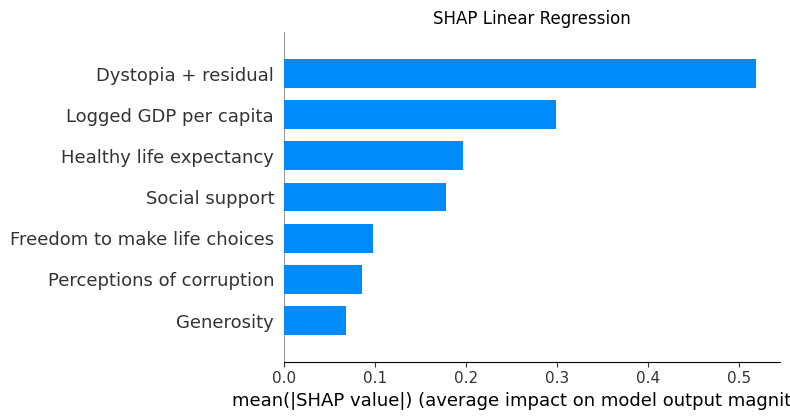

In [24]:
import shap


masker = shap.maskers.Independent(data=X_train_sc_minmax)
explainer_lr = shap.LinearExplainer(lr_minmax, masker)
shap_values_lr = explainer_lr.shap_values(X_test_sc_minmax)

shap.summary_plot(shap_values_lr, X_test_sc_minmax, feature_names=feature_names, plot_type='bar', show=False)
shap.initjs()
plt.title('SHAP Linear Regression')
plt.tight_layout()
plt.show()
shap.force_plot(explainer_lr.expected_value, shap_values_lr.mean(axis=0), feature_names=feature_names)

C:\Users\8dant\AppData\Local\Temp\ipykernel_6808\47428558.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gb, X_test_sc_minmax, feature_names=feature_names, plot_type='bar', show=False)


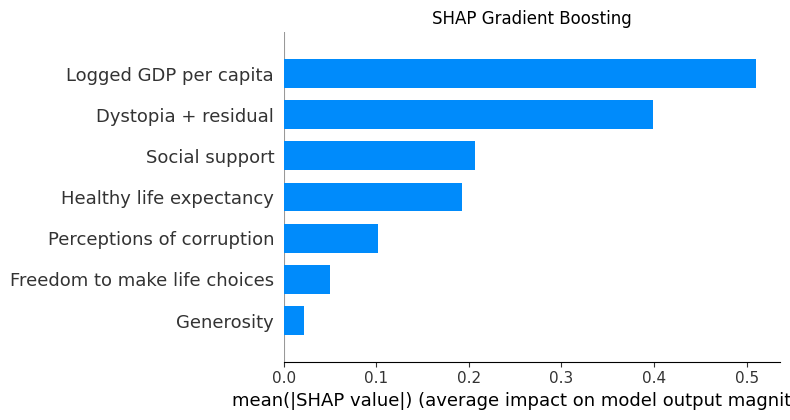

In [25]:
explainer_gb = shap.TreeExplainer(gb_minmax)
shap_values_gb = explainer_gb.shap_values(X_test_sc_minmax)

shap.summary_plot(shap_values_gb, X_test_sc_minmax, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Gradient Boosting')
plt.tight_layout()
plt.show()

shap.force_plot(explainer_gb.expected_value, shap_values_gb.mean(axis=0), feature_names=feature_names)

 **Ваш вывод здесь:**

Начнем в force графика:

Видим, что самый значительный эффект дает GPD, что объясняется размером (длиной) данного сектора (признака). Также видим, что те же признаки относятся к положительным и отрицательным, что мы получали ранее при других методах. Еще кажется что иерархия осталось +- той же, но Dystopia почему-то сильно ниже по важности, чем в других методах. Еще у признаков стало гораздо больше веса, чем было в других методах, что тоже необычно.

В случае обычного шапа можем сказать, что отоюражен средний модуль вклада каждого признака и иерархия аналогичная с предыдущими методами. Единственное видно, что у бустинга распределение важности более сглаженное особенно у самых важных признаков. Полагаю, что это связано с самой сложностью модели, бустинг позволяет находть нелинейную (более сложную зависимость), чем линейная модель, отсюда и отличия.

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

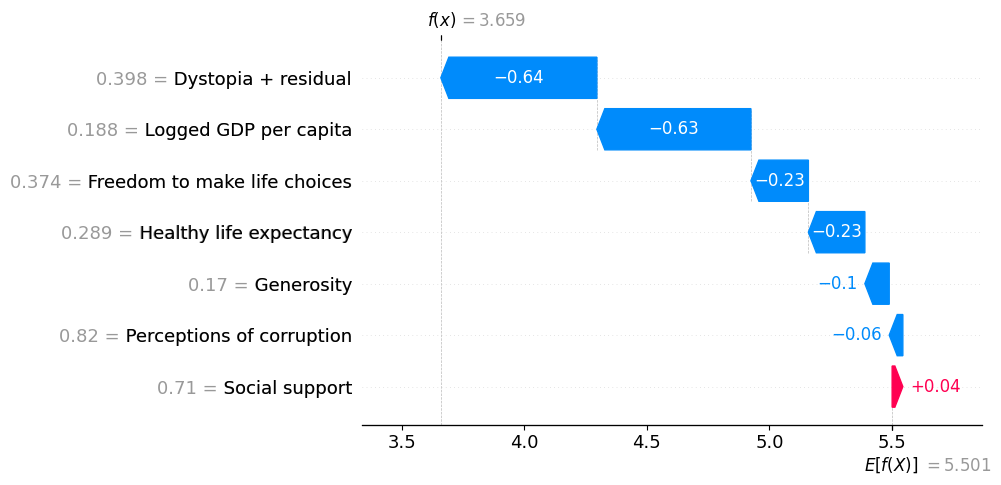

In [26]:
shap.waterfall_plot(shap.Explanation(values=shap_values_lr[7], base_values=explainer_lr.expected_value, data=X_test_sc_minmax[7], feature_names=feature_names))

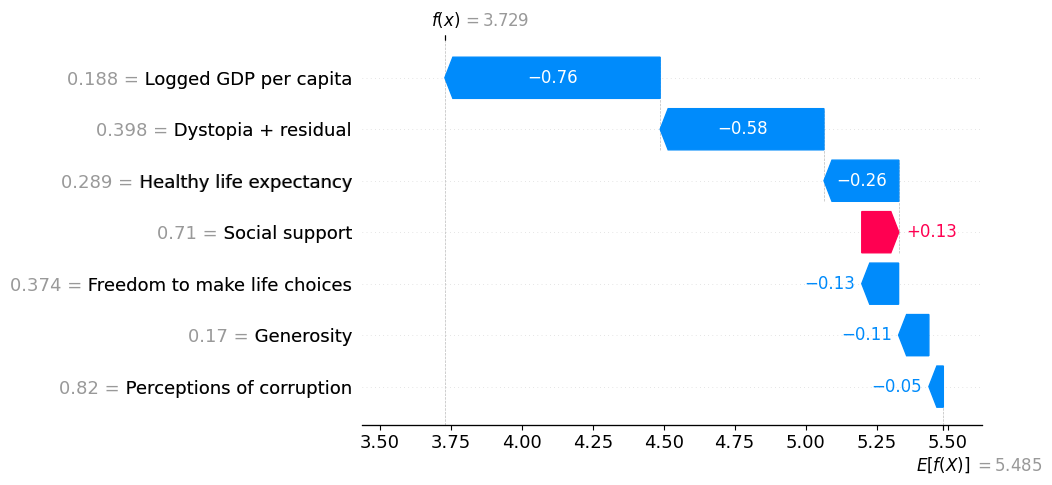

In [27]:
shap.waterfall_plot(shap.Explanation(values=shap_values_gb[7], base_values=explainer_gb.expected_value, data=X_test_sc_minmax[7], feature_names=feature_names))

**Ваш вывод здесь:**

На первом графике все еще видим, что те же признаки вносят наибольши вклад в прогноз, также сохраняется та же иерархия для линейной модели. Только вклады получились достаточно близкими -0.64 и -0.63, когда до этого они были достаточно далекими.


На втором графике мы получаем ту же иерархию при бустинге, что была для других методов оценки важности фичей. Топ 1 самая важная фича все так же отличается от линейной модели, но теперь значения в сравнении отличаются сильнее в бустинге, чем в линейной модели. В линейной модели многие признаки одинаковую важность имеют (в сравнении с более важным признаком по иерархии)



### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

In [80]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(training_data=X_train_sc_minmax, feature_names=feature_names, mode='regression', kernel_width=np.sqrt(len(feature_names)) * 0.75, discretize_continuous=False)

exp_lr = explainer_lime.explain_instance(X_test_sc_minmax[7], lr_minmax.predict, num_features=len(feature_names))
print('Интерсепт для линейной регрессии:', exp_lr.intercept[1])
exp_lr.as_list()

exp_gb = explainer_lime.explain_instance(X_test_sc_minmax[7], gb_minmax.predict, num_features=len(feature_names))
print('Интерсепт для градиентного бустинга:', exp_gb.intercept[1])
exp_gb.as_list()

Интерсепт для линейной регрессии: 5.484316530626996
Интерсепт для градиентного бустинга: 5.38717901071016


[('Dystopia + residual', 0.44575671697959546),
 ('Logged GDP per capita', 0.3947090950137253),
 ('Healthy life expectancy', 0.2022135264304531),
 ('Social support', 0.19931458934832424),
 ('Freedom to make life choices', 0.06617949386010409),
 ('Perceptions of corruption', -0.05870232967823997),
 ('Generosity', 0.0279436078698145)]

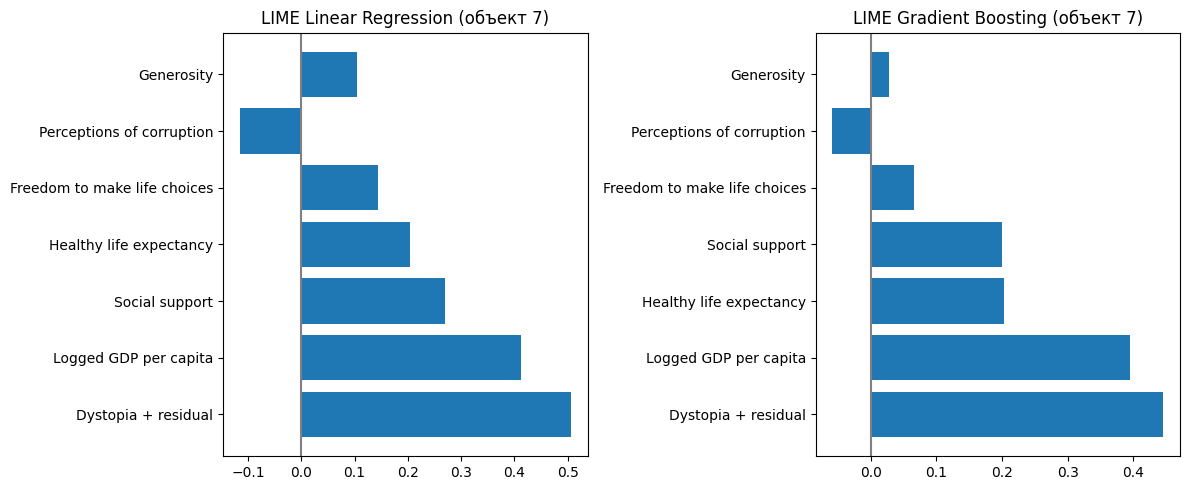

In [81]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
features_lr = [v[0] for v in exp_lr.as_list()]
weights_lr = [v[1] for v in exp_lr.as_list()]
ax1.barh(features_lr, weights_lr)
ax1.set_title('LIME Linear Regression (объект 7)')
ax1.axvline(0, color='gray')

features_gb = [v[0] for v in exp_gb.as_list()]
weights_gb = [v[1] for v in exp_gb.as_list()]
ax2.barh(features_gb, weights_gb)
ax2.set_title('LIME Gradient Boosting (объект 7)')
ax2.axvline(0, color='gray')

plt.tight_layout()
plt.show()

**Выводы:**

Видим, что иерархия +- та же. Почему-то в бустинге dystopia стала топ 1 по важности, что не было верно для shap и других методов. Самые весомые признаки тоже остались теми же, значит метод дал аналогичные результаты. Также такое большое количество совпадений значений важности при двух разных методах позволяет нам увеличить надежность полученных нами результатов. 


### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [98]:
from sklearn.metrics import pairwise_distances


def foo(model, X, x0, n, kernel_width):
    std = np.std(X, axis=0, ddof=0)
    samples = x0 + np.random.RandomState(42).randn(n, X.shape[1]) * std
    pred = model.predict(samples)
    distance = pairwise_distances(samples, [x0], metric='euclidean').ravel()
    weights = np.exp(-(distance ** 2) / (2 * kernel_width ** 2))
    scaler = StandardScaler().fit(X)
    samples_scaled = scaler.transform(samples)
    lr = LinearRegression()
    lr.fit(samples_scaled, pred, sample_weight=weights)
    return lr.coef_, lr.intercept_

In [99]:
x0 = X_test_sc_minmax[7]
coef, intercept = foo(gb_minmax, X_train_sc_minmax, x0, 200, np.sqrt(X_train_sc_minmax.shape[1]) * 0.75)

print(pd.Series(coef, index=feature_names).to_string())
print(f'Intercept: {intercept:.4f}')

Logged GDP per capita           0.218626
Social support                  0.214385
Healthy life expectancy         0.182536
Freedom to make life choices    0.050425
Generosity                      0.091662
Perceptions of corruption      -0.088604
Dystopia + residual             0.370606
Intercept: 5.2251


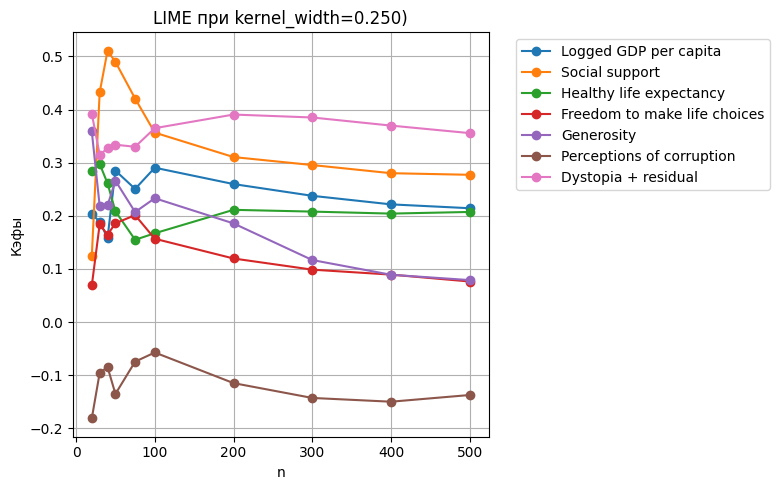

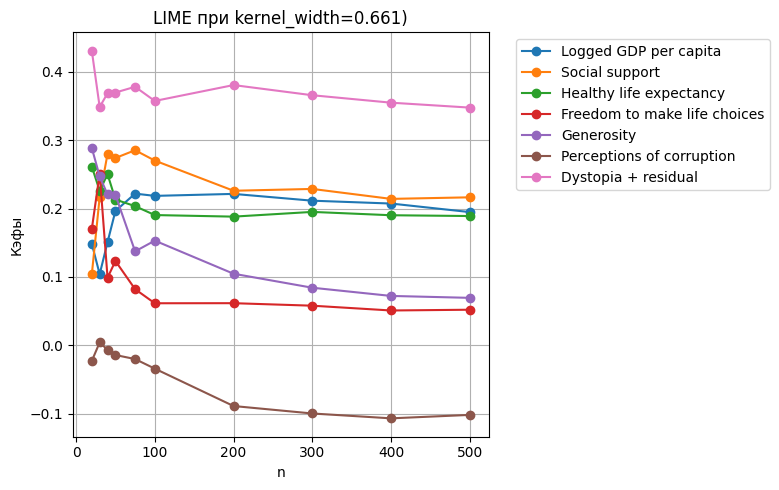

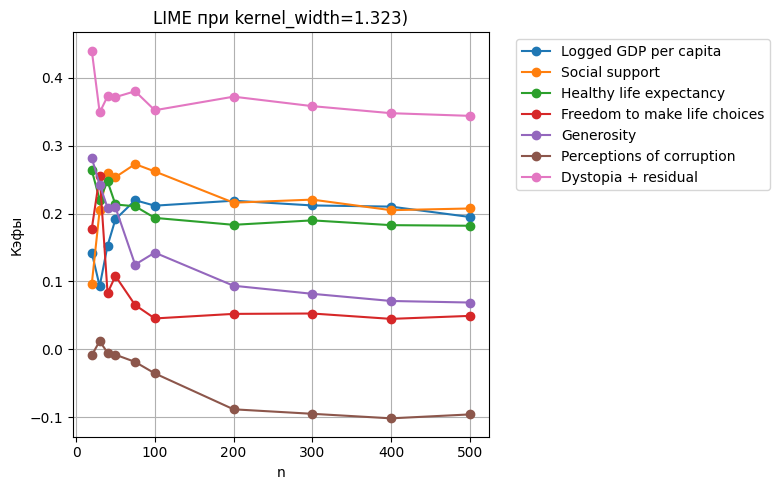

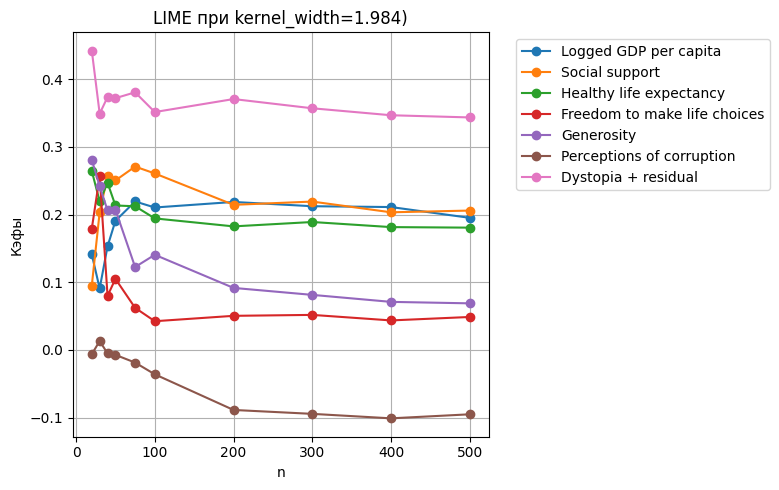

In [ ]:
values = [20, 30, 40, 50, 75, 100, 200, 300, 400, 500]
kernels = [0.25, np.sqrt(X_train_sc_minmax.shape[1]) * 0.25, np.sqrt(X_train_sc_minmax.shape[1]) * 0.5, np.sqrt(X_train_sc_minmax.shape[1]) * 0.75]

coefs = np.zeros((len(kernels), len(values), len(feature_names)))
for j in range(len(kernels)):
    kw = kernels[j]
    for i in range(len(values)):
        n = values[i]
        c, _ = foo(gb_minmax, X_train_sc_minmax, x0, n, kw)
        coefs[j, i, :] = c

for j in range(len(kernels)):
    kw = kernels[j]
    plt.figure(figsize=(8,5))
    for f in range(len(feature_names)):
        plt.plot(values, coefs[j, :, f], label=feature_names[f], marker='o')
    plt.xlabel('n')
    plt.ylabel('Кэфы')
    plt.title(f'LIME при kernel_width={kw:.3f})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Ваш вывод здесь:**

Чем выше n, тем лучше устойчивость. Это видно на всех графиках, в самом начале при малых n у нас там хаос для каждого признака, но потом при росте n значения все меньше и меньше друг от друга будут отличаться (начинают стабилизироваться)

Видим по вертикальной оси, что при увеличении ядра значения кэфов становятся менее изменчивыми. Полагаю, что это связано со сглаживанием локальных особенностей, приближая объяснение к глобальной линейной модели. Просто при маленьком ядре у нас большая локальная нестабильность. Но при увеличении ядра мы будем все больше отходить от локальных замеров в сторону более глобальных.

## **Вы проделали огромную работу! Ура!**